In [1]:
words=open('names.txt', 'r').read().splitlines()

In [3]:
len(words)

32033

In [5]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['E']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [7]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', 'E'), 6763),
 (('a', 'E'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', 'E'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', 'E'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', 'E'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', 'E'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', 'E'), 

In [9]:
import torch 

In [10]:
N = torch.zeros((28, 28), dtype = torch.int32)

In [13]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.']= 0
itos = {i:s for s,i in stoi.items()}

In [15]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2] 
        N[ix1,ix2] += 1

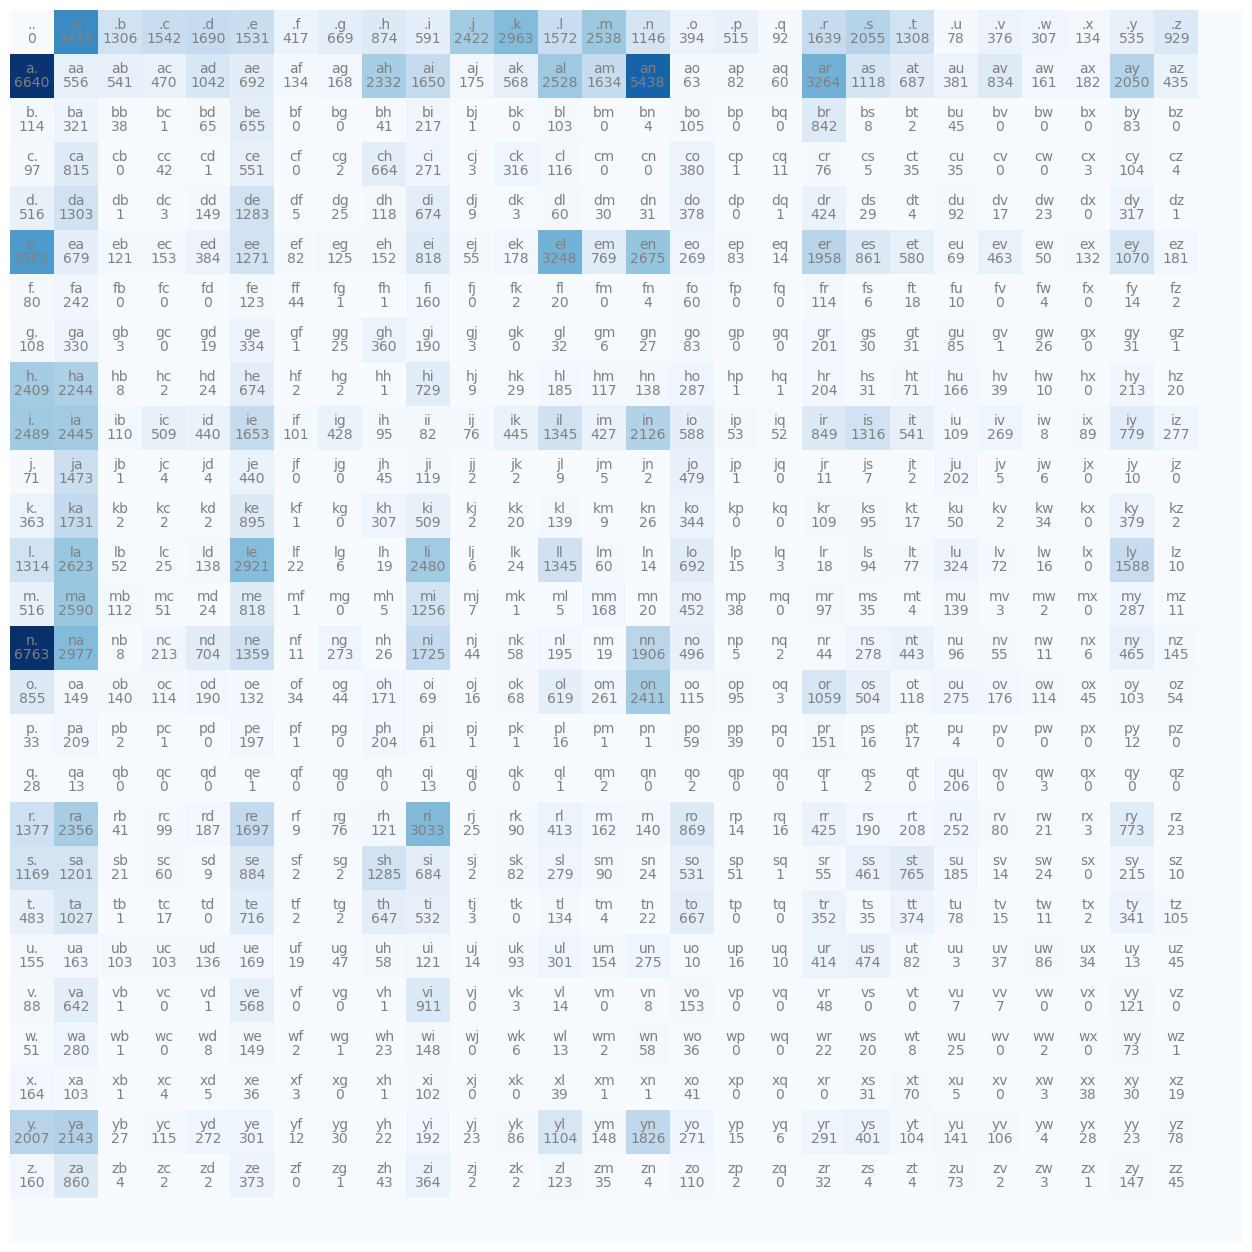

In [16]:
import math 
import matplotlib.pyplot as plt 
%matplotlib inline 

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color='gray')
plt.axis('off')
plt.show()

In [19]:
N[0, :]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929,    0], dtype=torch.int32)

In [21]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290,
        0.0000])

In [23]:
P = (N+1).float()
# N+1 for model smoothening 
P /= P.sum(1, keepdim=True)
# torch.sum(input, dim, keepdim=False, dtype=None) --> tensor, summing across the rows 
# we are doing the keepdim thing just to stretch the (28,1) across all 28 
# columns automatically — that's called broadcasting.
# check broadcasting semantics 

In [25]:
P.shape

torch.Size([28, 28])

In [27]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement = True, generator=g).item()
itos[ix]

'c'

In [29]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    ix = 0 
    out = []
    while True:
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement = True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
    

cava.
ayamaijowy.
aianeta.
rl.
miryndardyrioma.
kiinninaswila.
en.
ahlanyanlen.
tav.
sissth.


In [31]:
#Goal: maximize likelihood of the data wrt model parameters (statistical modeling)
#equivalent to maximize log likelihood (bcoz log is monotonic)
#equivalent to minimize negative log likelihood
#equivalent to minimize average negative log likelihood

In [33]:
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2] 
        prob = P[ix1,ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f}, {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559978.7500)
nll=tensor(559978.7500)
2.4544754028320312


In [40]:
# creating a training set 
xs, ys = [], []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2] 
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [42]:
xs

tensor([ 0,  5, 13, 13,  1])

In [44]:
ys

tensor([ 5, 13, 13,  1,  0])

In [52]:
import torch.nn.functional as F 
xenc = F.one_hot(xs, num_classes = 27).float()
xenc 

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [54]:
xenc.shape

torch.Size([5, 27])

In [66]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27))
xenc @ W
# (5, 27) @ (27, 27) --> (5,27)

tensor([[ 0.5874, -2.5625, -0.9666, -0.2848,  0.7349, -0.0165,  0.9542, -0.0062,
         -1.4001,  0.1319,  0.6957,  0.8845,  1.4651,  0.1780, -1.2687, -0.2929,
         -1.0032, -0.7313,  0.7876,  1.7144,  0.1575, -1.8341,  0.8011, -0.3494,
         -1.7026, -0.0617, -0.9079],
        [ 0.3777,  1.9119,  0.1629,  0.7198,  0.3178,  1.4929, -0.6404, -1.0269,
          0.3995, -0.4568, -1.3616, -1.3302,  1.1196,  0.6316, -0.4119, -2.0731,
         -0.7845, -1.2611, -0.0563,  0.3248,  1.9326, -0.0571,  0.8589,  0.3562,
          1.0919, -0.3938, -0.0268],
        [-1.1983, -0.7160,  0.1158,  1.3003, -0.5565,  0.9326, -1.6215, -0.6023,
          1.6055, -0.5701,  1.3876,  0.7214, -0.2685, -1.1585,  1.1551,  1.7654,
         -0.1198,  0.1372, -1.1095,  0.2174,  0.6852, -0.8138,  0.0356, -0.6396,
         -0.8612,  0.4432, -0.9393],
        [-1.1983, -0.7160,  0.1158,  1.3003, -0.5565,  0.9326, -1.6215, -0.6023,
          1.6055, -0.5701,  1.3876,  0.7214, -0.2685, -1.1585,  1.1551,  1.7654

In [68]:
logits = (xenc @ W) # log-counts 
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs

tensor([[0.0494, 0.0021, 0.0104, 0.0207, 0.0573, 0.0270, 0.0713, 0.0273, 0.0068,
         0.0313, 0.0551, 0.0665, 0.1188, 0.0328, 0.0077, 0.0205, 0.0101, 0.0132,
         0.0604, 0.1525, 0.0321, 0.0044, 0.0612, 0.0194, 0.0050, 0.0258, 0.0111],
        [0.0318, 0.1475, 0.0257, 0.0448, 0.0300, 0.0970, 0.0115, 0.0078, 0.0325,
         0.0138, 0.0056, 0.0058, 0.0668, 0.0410, 0.0144, 0.0027, 0.0099, 0.0062,
         0.0206, 0.0302, 0.1506, 0.0206, 0.0515, 0.0311, 0.0649, 0.0147, 0.0212],
        [0.0073, 0.0119, 0.0273, 0.0893, 0.0139, 0.0618, 0.0048, 0.0133, 0.1211,
         0.0138, 0.0974, 0.0500, 0.0186, 0.0076, 0.0772, 0.1421, 0.0216, 0.0279,
         0.0080, 0.0302, 0.0483, 0.0108, 0.0252, 0.0128, 0.0103, 0.0379, 0.0095],
        [0.0073, 0.0119, 0.0273, 0.0893, 0.0139, 0.0618, 0.0048, 0.0133, 0.1211,
         0.0138, 0.0974, 0.0500, 0.0186, 0.0076, 0.0772, 0.1421, 0.0216, 0.0279,
         0.0080, 0.0302, 0.0483, 0.0108, 0.0252, 0.0128, 0.0103, 0.0379, 0.0095],
        [0.0912, 0.0037,

In [70]:
nlls = torch.zeros(5)
for i in range(5):
    # ith bigram 
    x = xs[i].item() #input character index
    y = ys[i].item() #label character index 
    print('--------')
    print(f'bigram exmaple {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:',x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p=probs[i,y]
    print('probability assigned by the net to the correct character:', p.item())
    logp=torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i]=nll

print('========')
print('average negative log likelihood, i.e loss =', nlls.mean().item())



--------
bigram exmaple 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0494, 0.0021, 0.0104, 0.0207, 0.0573, 0.0270, 0.0713, 0.0273, 0.0068,
        0.0313, 0.0551, 0.0665, 0.1188, 0.0328, 0.0077, 0.0205, 0.0101, 0.0132,
        0.0604, 0.1525, 0.0321, 0.0044, 0.0612, 0.0194, 0.0050, 0.0258, 0.0111])
label (actual next character): 5
probability assigned by the net to the correct character: 0.027006831020116806
log likelihood: -3.6116654872894287
negative log likelihood: 3.6116654872894287
--------
bigram exmaple 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0318, 0.1475, 0.0257, 0.0448, 0.0300, 0.0970, 0.0115, 0.0078, 0.0325,
        0.0138, 0.0056, 0.0058, 0.0668, 0.0410, 0.0144, 0.0027, 0.0099, 0.0062,
        0.0206, 0.0302, 0.1506, 0.0206, 0.0515, 0.0311, 0.0649, 0.0147, 0.0212])
label (actual next character): 13
probability assigned by the net to the correct character: 0.04098

In [72]:
 # ---------- !!! OPTIMIAZATION YAY  (understanding part )!!! ---------- #


In [74]:
xs 

tensor([ 0,  5, 13, 13,  1])

In [76]:
ys

tensor([ 5, 13, 13,  1,  0])

In [78]:
# randomly initialize 27 nerons' weights. each neruon receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)


In [138]:
# forward pass
xenc = F.one_hot(xs,num_classes=27).float()
logits = xenc @ W # predict log counts 
counts = logits.exp() # counts, equivalent to N 
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character 
loss = -probs[torch.arange(5),ys].log().mean()


In [140]:
print(loss.item())

3.6295523643493652


In [142]:
# backward pass
W.grad = None # set to zero the gradient 
loss.backward()
#w.grad is telling the influence of every weight (27,27) on the loss function 


In [144]:
# update 
W.data += -0.1 * W.grad 

In [146]:
 # ---------- !!! OPTIMIAZATION YAY  (actually)!!! ---------- #


In [148]:
# create the dataset 
xs, ys = [], []
for w in words:
    chs = ['.'] +list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of exmaples: ', num)

# intialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)


number of exmaples:  228146


In [152]:
# gradient descent 
for k in range(10):
    # forward pass 
    xenc = F.one_hot(xs,num_classes=27).float()
    logits = xenc @ W # predict log counts 
    counts = logits.exp() # counts, equivalent to N 
    probs = counts / counts.sum(1, keepdims=True) # probabilities for next character 
    loss = -probs[torch.arange(num),ys].log().mean()
    print(loss.item())

    #backward pass
    W.grad = None # set to zero the gradient 
    loss.backward()

    #update
    W.data += -50 * W.grad 

2.6890032291412354
2.6696884632110596
2.6529300212860107
2.638277292251587
2.6253879070281982
2.613990545272827
2.60386323928833
2.5948216915130615
2.5867116451263428
2.5794036388397217
